# 02 — Feature Engineering

Construction des features temporelles, metadata langages, AI susceptibility score.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loading import build_unified_panel, normalize_language_name, DATA_RAW
from src.features import (
    compute_temporal_features, build_multisource_features,
    compute_targets, analyze_threshold_candidates,
    build_language_metadata, DECLINE_THRESHOLD,
    MANUAL_AI_SCORES,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
FIGURES_DIR = '../reports/figures'

## 1. Chargement du panel et features temporelles

In [2]:
# Load unified panel
panel = pd.read_parquet('../data/processed/language_panel.parquet')
print(f"Panel: {panel.shape[0]} rows, {panel.language.nunique()} languages")

# Add temporal features (handles gaps properly)
panel_temporal = compute_temporal_features(panel)

# Show example: JavaScript in SO with gap annotation
js_so = panel_temporal[(panel_temporal.language == 'JavaScript') & (panel_temporal.source == 'stackoverflow')]
print("\nJavaScript (SO) — temporal features with gap handling:")
print(js_so[['year', 'usage_pct', 'delta_since_last_obs', 'years_since_last_obs', 
             'delta_annualized', 'rank']].to_string(index=False))
print("\nNote: years_since_last_obs = 2.0 pour 2018→2020 et 2020→2022 (gaps dans les surveys SO)")

Panel: 1987 rows, 206 languages

JavaScript (SO) — temporal features with gap handling:
 year  usage_pct  delta_since_last_obs  years_since_last_obs  delta_annualized  rank
 2017  62.457338                   NaN                   NaN               NaN   1.0
 2018  69.811321              7.353983                   1.0          7.353983   1.0
 2020  67.660079             -2.151242                   2.0         -1.075621   1.0
 2022  65.435717             -2.224362                   2.0         -1.112181   1.0
 2023  63.932752             -1.502965                   1.0         -1.502965   1.0
 2024  62.753368             -1.179383                   1.0         -1.179383   1.0

Note: years_since_last_obs = 2.0 pour 2018→2020 et 2020→2022 (gaps dans les surveys SO)


## 2. Features multi-sources et consensus

In [3]:
# Build multi-source features: pivots SO/GitHub/TIOBE + consensus
features = build_multisource_features(panel_temporal)
print(f"Features panel: {features.shape}")
print(f"Columns: {list(features.columns)}")
print(f"\nSample (Python):")
print(features[features.language == 'Python'][
    ['language', 'year', 'usage_pct_stackoverflow', 'usage_pct_github', 'usage_pct_tiobe',
     'usage_pct_mean', 'sources_agreement', 'n_sources_available']
].to_string(index=False))

Features panel: (1568, 18)
Columns: ['language', 'year', 'usage_pct_github', 'usage_pct_stackoverflow', 'usage_pct_tiobe', 'delta_ann_github', 'delta_ann_stackoverflow', 'delta_ann_tiobe', 'rank_github', 'rank_stackoverflow', 'rank_tiobe', 'volatility_github', 'volatility_stackoverflow', 'volatility_tiobe', 'n_respondents', 'usage_pct_mean', 'sources_agreement', 'n_sources_available']

Sample (Python):
language  year  usage_pct_stackoverflow  usage_pct_github  usage_pct_tiobe  usage_pct_mean  sources_agreement  n_sources_available
  Python  2004                      NaN               NaN         2.713333        2.713333                NaN                    1
  Python  2005                      NaN               NaN         3.124167        3.124167                NaN                    1
  Python  2006                      NaN               NaN         3.818333        3.818333                NaN                    1
  Python  2007                      NaN               NaN         4.34

## 3. AI Susceptibility Score (hybride manuel + data-driven)

In [4]:
# Compute data-driven AI adoption rate per language from SO 2023+2024
frames = []
for year in [2023, 2024]:
    lang_col = 'LanguageHaveWorkedWith'
    df = pd.read_csv(f'../data/raw/so_survey_{year}/survey_results_public.csv',
                     usecols=[lang_col, 'AISelect'], low_memory=False)
    df = df.dropna(subset=[lang_col, 'AISelect'])
    df['uses_ai'] = (df['AISelect'] == 'Yes').astype(int)
    
    exploded = df[[lang_col, 'uses_ai']].copy()
    exploded[lang_col] = exploded[lang_col].str.split(';')
    exploded = exploded.explode(lang_col)
    exploded[lang_col] = exploded[lang_col].str.strip().map(normalize_language_name)
    exploded = exploded.dropna(subset=[lang_col])
    
    by_lang = exploded.groupby(lang_col)['uses_ai'].agg(['mean', 'count']).reset_index()
    by_lang.columns = ['language', 'ai_adoption_rate', 'n_users']
    by_lang['year'] = year
    frames.append(by_lang)

ai_combined = pd.concat(frames)
ai_adoption = ai_combined.groupby('language').apply(
    lambda g: pd.Series({
        'ai_adoption_rate': (g['ai_adoption_rate'] * g['n_users']).sum() / g['n_users'].sum(),
        'total_users': g['n_users'].sum()
    })
).reset_index()
ai_adoption = ai_adoption[ai_adoption.total_users >= 100]

# Build metadata with hybrid score
metadata = build_language_metadata(ai_adoption)
metadata.to_csv('../data/processed/language_metadata.csv', index=False)
print(f"Language metadata: {len(metadata)} languages")
print(f"\nScore = 0.5 * manual + 0.5 * data-driven (AI adoption rate from SO 2023+2024)")
print(f"Languages with data-driven component: {metadata.ai_adoption_data.notna().sum()}")
print(f"Languages with manual-only score: {metadata.ai_adoption_data.isna().sum()}")

# Top 10 + Bottom 10
print(f"\n{'='*60}")
print(f"TOP 10 — Highest AI susceptibility (most generable by LLM)")
print(f"{'='*60}")
top10 = metadata.nlargest(10, 'ai_susceptibility_score')
print(top10[['language', 'ai_susceptibility_manual', 'ai_adoption_data', 
             'ai_susceptibility_score']].to_string(index=False))

print(f"\n{'='*60}")
print(f"BOTTOM 10 — Lowest AI susceptibility (hardest to generate)")
print(f"{'='*60}")
bot10 = metadata.nsmallest(10, 'ai_susceptibility_score')
print(bot10[['language', 'ai_susceptibility_manual', 'ai_adoption_data', 
             'ai_susceptibility_score']].to_string(index=False))

Language metadata: 53 languages

Score = 0.5 * manual + 0.5 * data-driven (AI adoption rate from SO 2023+2024)
Languages with data-driven component: 50
Languages with manual-only score: 3

TOP 10 — Highest AI susceptibility (most generable by LLM)
    language  ai_susceptibility_manual ai_adoption_data  ai_susceptibility_score
CoffeeScript                      0.85             <NA>                 0.850000
        Dart                      0.80         0.654298                 0.727149
  JavaScript                      0.90         0.553479                 0.726739
         PHP                      0.90         0.542843                 0.721422
  TypeScript                      0.85         0.592019                 0.721009
        Ruby                      0.85         0.533583                 0.691792
      VB.NET                      0.90         0.477375                 0.688688
         VBA                      0.90         0.466994                 0.683497
         SQL           

## 4. Merge metadata dans le features panel + ajout age du langage

In [5]:
# Merge metadata into features
meta_cols = ['language', 'ai_susceptibility_score', 'ai_susceptibility_manual',
             'ai_adoption_data', 'year_created', 'typing', 'compiled', 'level', 'paradigm']
features_enriched = features.merge(
    metadata[meta_cols], on='language', how='left'
)

# Compute language age at each year
features_enriched['language_age'] = features_enriched['year'] - pd.to_numeric(features_enriched['year_created'], errors='coerce')

# Encode categorical features for modeling (handle NaN properly)
features_enriched['is_static_typed'] = (features_enriched['typing'] == 'static').astype(float)
features_enriched['is_compiled'] = pd.to_numeric(features_enriched['compiled'], errors='coerce')

level_map = {'low': 0, 'mid': 1, 'high': 2}
features_enriched['level_num'] = features_enriched['level'].map(level_map)

print(f"Enriched features: {features_enriched.shape}")
print(f"\nNew columns added: language_age, is_static_typed, is_compiled, level_num, ai_susceptibility_score")
print(f"\nSample (Rust):")
print(features_enriched[features_enriched.language == 'Rust'][
    ['language', 'year', 'usage_pct_stackoverflow', 'ai_susceptibility_score',
     'language_age', 'is_static_typed', 'is_compiled', 'level_num']
].to_string(index=False))

Enriched features: (1568, 30)

New columns added: language_age, is_static_typed, is_compiled, level_num, ai_susceptibility_score

Sample (Rust):
language  year  usage_pct_stackoverflow  ai_susceptibility_score  language_age  is_static_typed  is_compiled  level_num
    Rust  2004                      NaN                 0.360477          -6.0              1.0          1.0        0.0
    Rust  2005                      NaN                 0.360477          -5.0              1.0          1.0        0.0
    Rust  2006                      NaN                 0.360477          -4.0              1.0          1.0        0.0
    Rust  2007                      NaN                 0.360477          -3.0              1.0          1.0        0.0
    Rust  2008                      NaN                 0.360477          -2.0              1.0          1.0        0.0
    Rust  2009                      NaN                 0.360477          -1.0              1.0          1.0        0.0
    Rust  2010 

## 5. Calibration du seuil de declin (target)

Threshold calibration (SO data, relative change over ~2 years):
threshold  n_decline  n_stable_growth  pct_decline  n_total
     -10%         42               65    39.252336      107
     -15%         29               78    27.102804      107
     -20%         24               83    22.429907      107
     -25%         18               89    16.822430      107


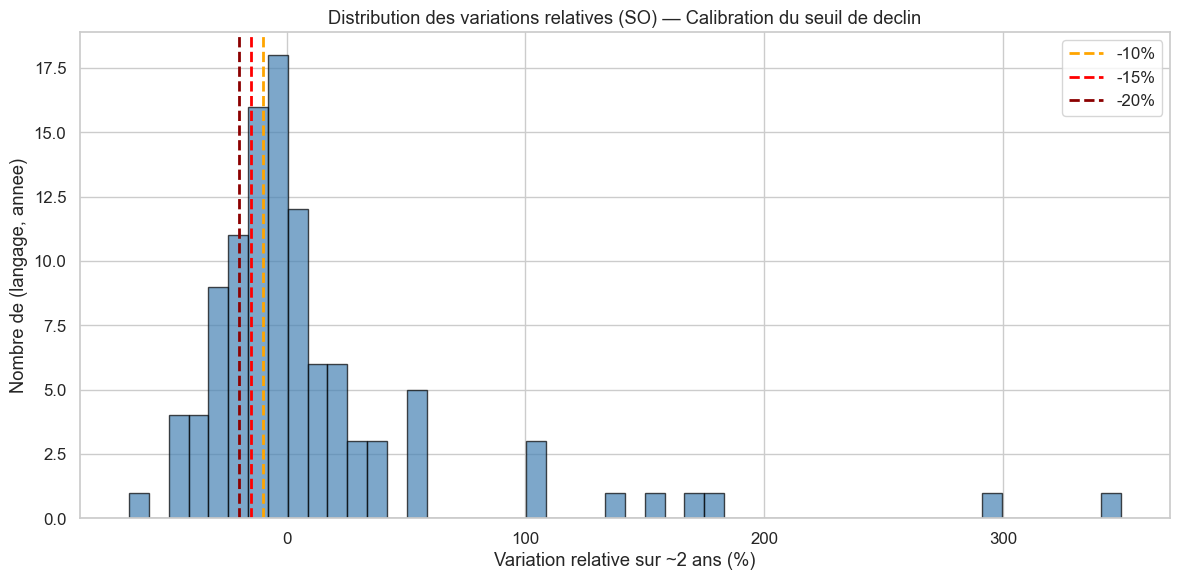


Seuil retenu: -15% (variable DECLINE_THRESHOLD dans src/features.py)
Justification: equilibre ~30% de declin, evite les classes trop desequilibrees.


In [6]:
# Analyze threshold candidates on SO data
# Only use rows where SO data is available (primary target source)
so_features = features_enriched[features_enriched.usage_pct_stackoverflow.notna()].copy()

threshold_analysis = analyze_threshold_candidates(so_features)
print("Threshold calibration (SO data, relative change over ~2 years):")
print(threshold_analysis.to_string(index=False))

# Distribution histogram of relative changes
grp = so_features.sort_values(['language', 'year']).groupby('language')
so_features['_t2'] = grp['usage_pct_stackoverflow'].shift(-2)
so_features['_y2'] = grp['year'].shift(-2)
valid = so_features['_y2'].sub(so_features['year']).between(1, 4) & (so_features['usage_pct_stackoverflow'] > 0)
rel_changes = ((so_features['_t2'] - so_features['usage_pct_stackoverflow']) / so_features['usage_pct_stackoverflow']).where(valid).dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(rel_changes * 100, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
for thresh, color in [(-10, 'orange'), (-15, 'red'), (-20, 'darkred')]:
    ax.axvline(x=thresh, color=color, linestyle='--', linewidth=2, label=f'{thresh}%')
ax.set_xlabel('Variation relative sur ~2 ans (%)')
ax.set_ylabel('Nombre de (langage, annee)')
ax.set_title('Distribution des variations relatives (SO) — Calibration du seuil de declin')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_07_threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp cols
so_features.drop(columns=['_t2', '_y2'], inplace=True)

print(f"\nSeuil retenu: {DECLINE_THRESHOLD:.0%} (variable DECLINE_THRESHOLD dans src/features.py)")
print("Justification: equilibre ~30% de declin, evite les classes trop desequilibrees.")

## 6. Calcul des targets et sauvegarde finale

In [7]:
# Compute targets
features_final = compute_targets(features_enriched)

# Save
features_final.to_parquet('../data/processed/features_panel.parquet', index=False)

print(f"features_panel.parquet: {features_final.shape[0]} rows x {features_final.shape[1]} columns")
print(f"\nTarget distribution (decline, seuil {DECLINE_THRESHOLD:.0%}):")
print(features_final['decline'].value_counts(dropna=False).to_string())

target_valid = features_final['decline'].dropna()
pct_decline = (target_valid == 1).mean() * 100
print(f"\n% decline (parmi ceux avec target valide): {pct_decline:.1f}%")
print(f"Nombre de lignes avec target valide: {len(target_valid)}")
print(f"Nombre de lignes sans target (annees recentes, pas de t+2): {features_final['decline'].isna().sum()}")

features_panel.parquet: 1568 rows x 33 columns

Target distribution (decline, seuil -15%):
decline
<NA>    1481
0         66
1         21

% decline (parmi ceux avec target valide): 24.1%
Nombre de lignes avec target valide: 87
Nombre de lignes sans target (annees recentes, pas de t+2): 1481


## 7. Analyse des NaN et matrice de correlation

In [8]:
# NaN analysis
nan_pct = features_final.isnull().mean().sort_values(ascending=False) * 100
nan_report = nan_pct[nan_pct > 0]
print("Colonnes avec NaN (% du total):")
print(nan_report.to_string())
print(f"\nExplication des NaN:")
print("- usage_pct_stackoverflow: langages uniquement dans GitHub/TIOBE (pas dans SO)")
print("- usage_pct_github: langages uniquement dans SO/TIOBE (pas dans GitHub)")
print("- usage_pct_tiobe: langages pas suivis par TIOBE (niche)")
print("- delta_*: premiere observation de chaque serie (pas de precedent)")
print("- ai_*: langages sans metadata manuelle ou < 100 repondants SO AI")
print("- target columns: annees recentes sans observation t+2")
print("- n_respondents: NaN pour sources non-SO (GitHub, TIOBE)")
print("\n→ Strategie: PAS d'imputation agressive. XGBoost/LightGBM gerent les NaN nativement.")

Colonnes avec NaN (% du total):
decline                     94.451531
relative_change_2y          94.451531
delta_ann_stackoverflow     88.647959
volatility_stackoverflow    88.647959
target_usage_pct_t2         86.224490
rank_stackoverflow          85.076531
usage_pct_stackoverflow     85.076531
n_respondents               85.076531
sources_agreement           77.742347
delta_ann_tiobe             63.010204
volatility_tiobe            63.010204
rank_tiobe                  61.160714
usage_pct_tiobe             61.160714
year_created                52.806122
level_num                   52.806122
compiled                    52.806122
is_compiled                 52.806122
language_age                52.806122
ai_adoption_data            50.701531
ai_susceptibility_manual    47.385204
typing                      47.385204
level                       47.385204
paradigm                    47.385204
ai_susceptibility_score     47.385204
delta_ann_github            39.668367
volatility_github 

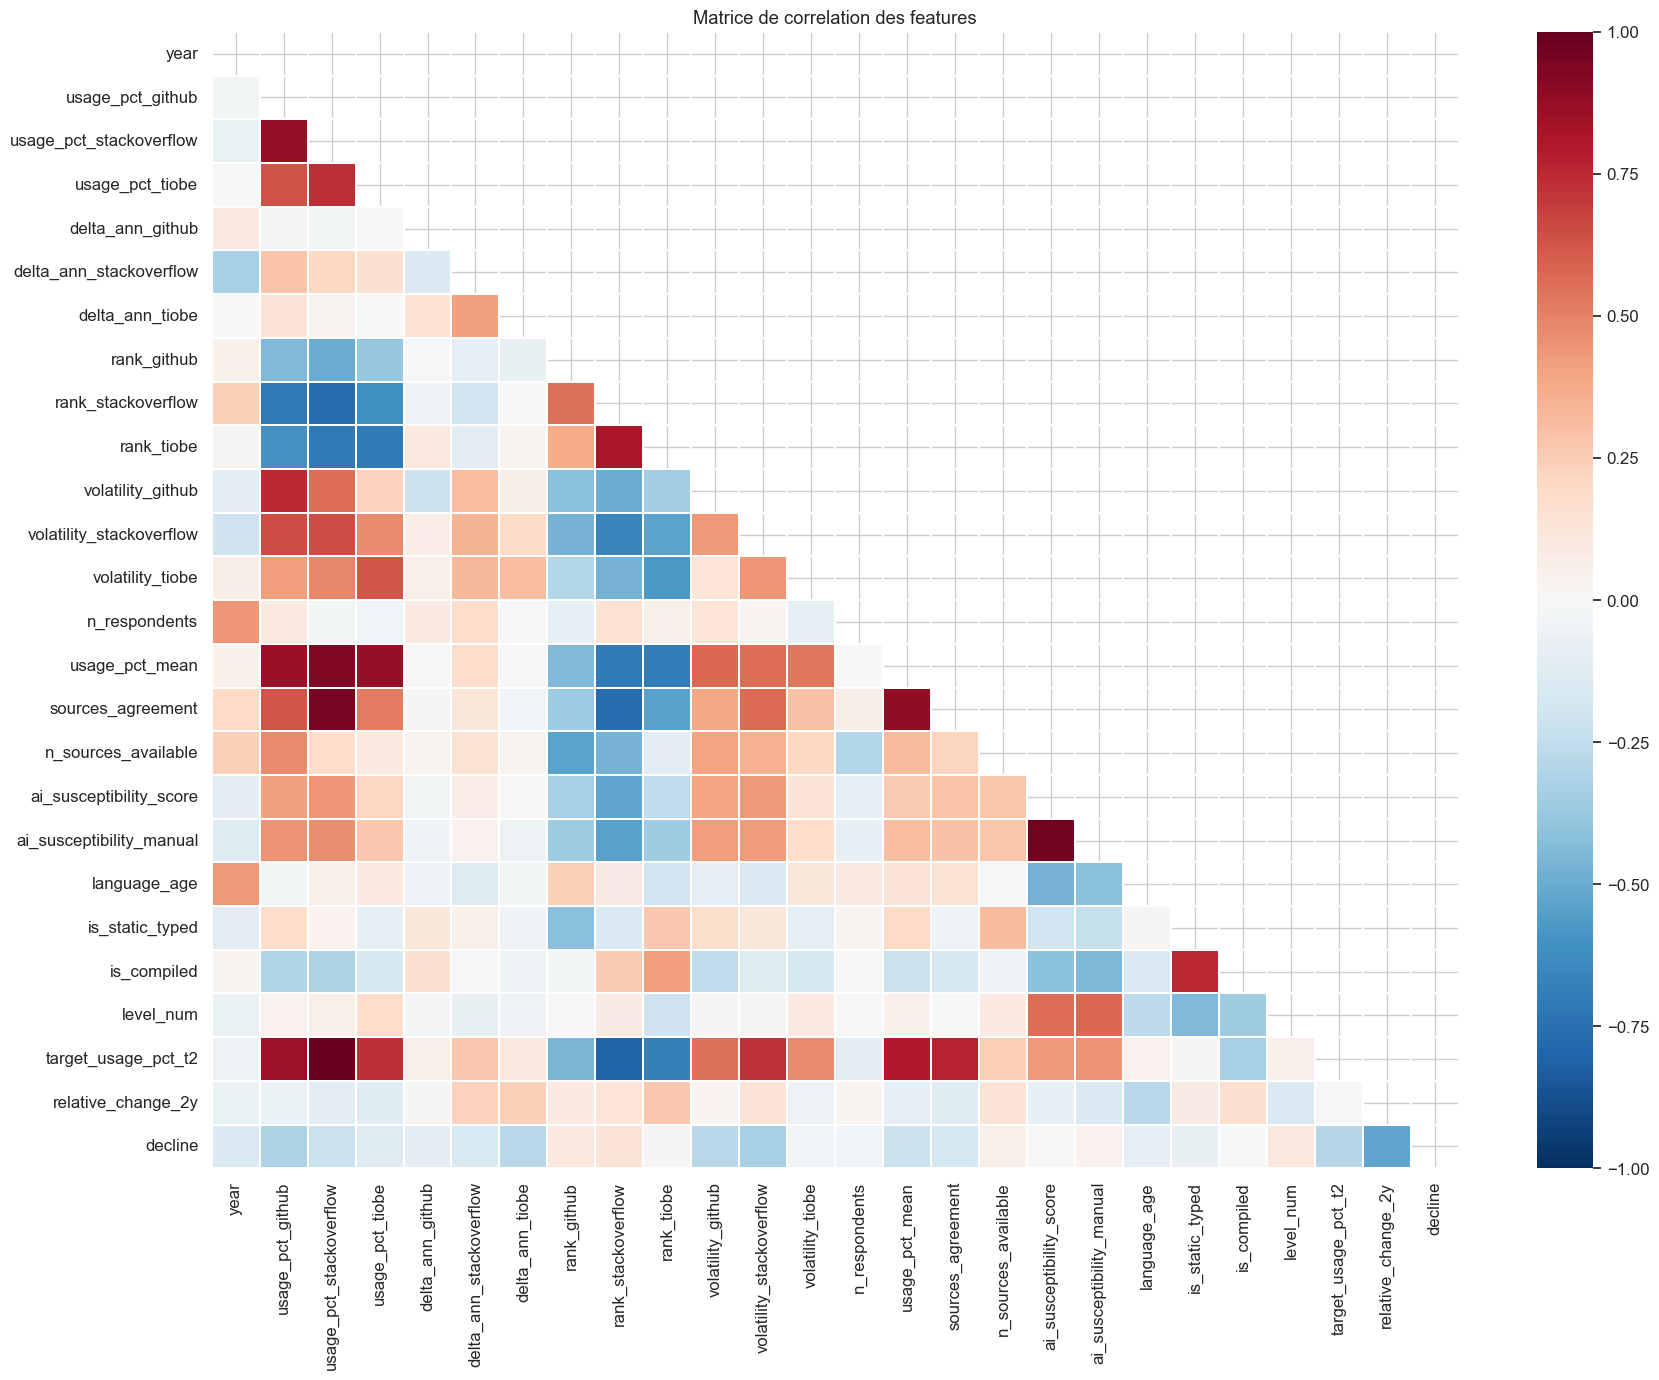

Correlations avec la target 'decline':
relative_change_2y         -0.529556
volatility_stackoverflow   -0.328789
usage_pct_github           -0.313773
target_usage_pct_t2        -0.282035
volatility_github          -0.276085
ai_susceptibility_manual    0.040066
n_sources_available         0.054893
level_num                   0.106369
rank_github                 0.107566
rank_stackoverflow          0.137407


In [9]:
# Correlation matrix of numeric features
numeric_cols = features_final.select_dtypes(include=[np.number]).columns
# Filter to meaningful columns (drop internal IDs)
corr_cols = [c for c in numeric_cols if c not in ['year_created'] and not c.startswith('_')]
corr_matrix = features_final[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de correlation des features')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlations with target
if 'decline' in corr_cols:
    target_corr = corr_matrix['decline'].drop('decline').dropna().sort_values()
    print("Correlations avec la target 'decline':")
    print(pd.concat([target_corr.head(5), target_corr.tail(5)]).to_string())